# Task 2 part 1
Here we want to identify which genetic perturbations show similar effects. To do this we cluster the cells first individually and then in a pseudobulk approach for each perturbation in each condition

In [2]:
# load the filtered RNA data as anndata object
import anndata as ad

data_dir = "/home/ubuntu/data/frangieh"

rna_filtered = ad.read_h5ad(f"{data_dir}/rna_qc_filtered.h5ad")

In [3]:
# Store counts in a separate layer before transforming the data
rna_filtered.layers["counts"] = rna_filtered.X.copy()

In [4]:
# normalize the data to 10000 counts per cell and log-transform the data with a pseudocount of 1
import scanpy as sc
sc.pp.normalize_total(rna_filtered, target_sum = 1e4)
sc.pp.log1p(rna_filtered)

In [5]:
rna_filtered.obs["perturbation_2"].value_counts()

perturbation_2
IFNγ          85100
Co-culture    71143
Control       57627
Name: count, dtype: int64

In [6]:
# split the dataset by perturbation_2 and store the resulting datasets
rna_filtered_split = {
    cond: rna_filtered[rna_filtered.obs["perturbation_2"] == cond].copy()
    for cond in rna_filtered.obs["perturbation_2"].unique()
}

In [7]:
# compute highly variable genes for each split dataset and store them for each split
for key in rna_filtered_split.keys():
    sc.pp.highly_variable_genes(rna_filtered_split[key], n_top_genes = 2000)

In [8]:
# compute PCA for each split dataset 
for key in rna_filtered_split.keys():
    sc.tl.pca(rna_filtered_split[key])

In [14]:
# inspect observations to decide on coloring of pca plots 
rna_filtered_split["Control"].obs.head()

,library_preparation_protocol,perturbation_2,MOI,sgRNA,UMI_count,guide_id,perturbation,tissue_type,cancer,disease,...,ngenes,ncounts,percent_mito,percent_ribo,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,doublet_score,predicted_doublet
cell_name,,,,,,,,,,,,,,,,,,,,,
CELL_1,10X 3' v3 sequencing,Control,1,HLA-B_2,10832.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,...,3520,10832.0,3.618907,12.943131,3520,10832.0,392.0,3.618907,0.023793,False
CELL_2,10X 3' v3 sequencing,Control,2,nan,10731.0,NGFR_3;SERPINF1_3,NGFR,cell_line_co-culture,True,melanoma,...,3531,10731.0,4.864412,12.701519,3531,10731.0,522.0,4.864411,0.029975,False
CELL_3,10X 3' v3 sequencing,Control,1,HLA-B_2,28821.0,HLA-B_2,HLA-B,cell_line_co-culture,True,melanoma,...,5541,28821.0,4.250373,12.348635,5541,28821.0,1225.0,4.250373,0.054465,False
CELL_4,10X 3' v3 sequencing,Control,2,nan,15322.0,NMRK1_3;S100A6_3,NMRK1,cell_line_co-culture,True,melanoma,...,4086,15322.0,5.743376,15.272158,4086,15322.0,880.0,5.743375,0.052039,False
CELL_5,10X 3' v3 sequencing,Control,0,nan,10314.0,nan,control,cell_line_co-culture,True,melanoma,...,3178,10314.0,5.497382,15.105682,3178,10314.0,567.0,5.497382,0.104093,False


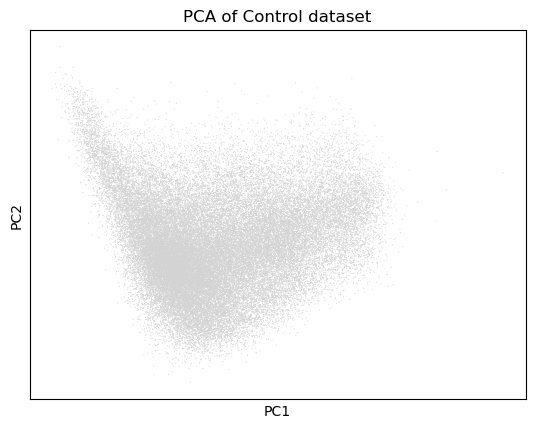

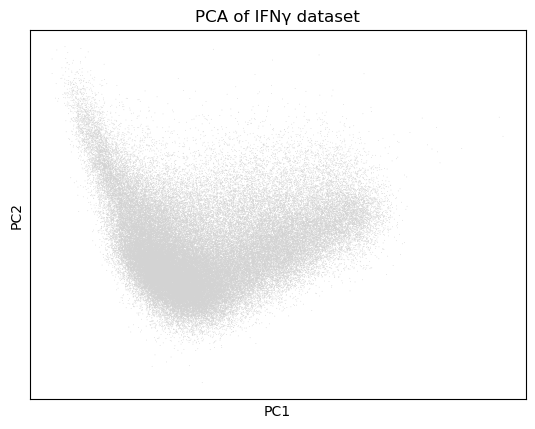

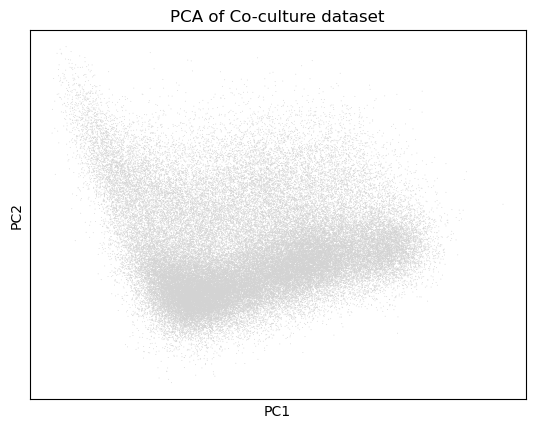

In [18]:
# plot PCA for each split dataset twice
for key in rna_filtered_split.keys():
    sc.pl.pca(rna_filtered_split[key], dimensions = (0, 1), title = f"PCA of {key} dataset")

In [19]:
# compute neighbors and UMAP for each split 
for key in rna_filtered_split.keys():
    sc.pp.neighbors(rna_filtered_split[key])
    sc.tl.umap(rna_filtered_split[key])

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


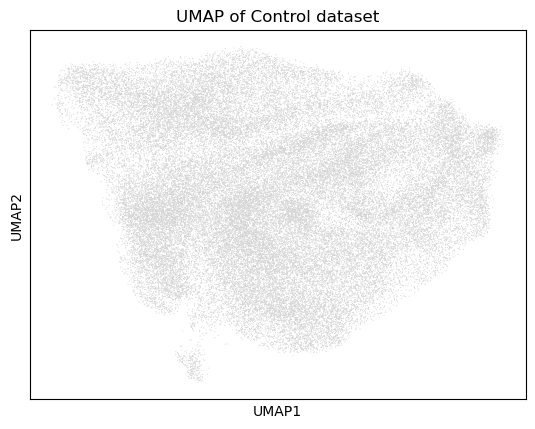

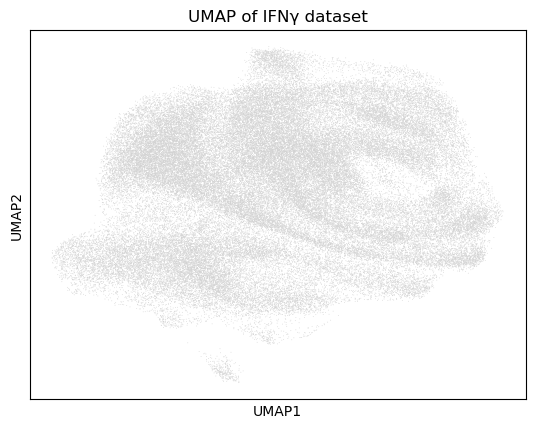

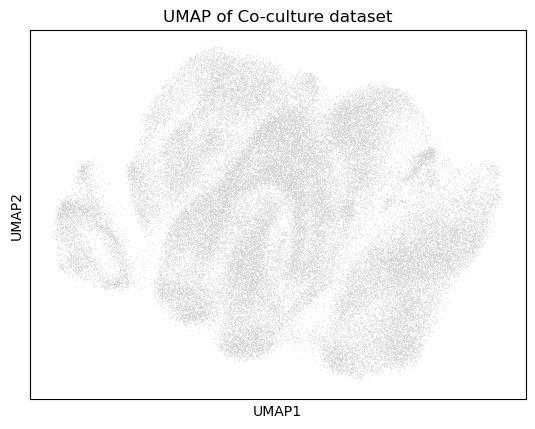

In [20]:
# plot the umaps for each split dataset
for key in rna_filtered_split.keys():
    sc.pl.umap(rna_filtered_split[key], title = f"UMAP of {key} dataset")

In [22]:
# compute leiden clusters with varied resolution
for key in rna_filtered_split.keys():
    sc.tl.leiden(rna_filtered_split[key], resolution = 0.5, key_added = "leiden_0.5", flavor = 'igraph', n_iterations = 2, directed = False)
    sc.tl.leiden(rna_filtered_split[key], resolution = 1.0, key_added = "leiden_1.0", flavor = 'igraph', n_iterations = 2, directed = False)
    sc.tl.leiden(rna_filtered_split[key], resolution = 2.0, key_added = "leiden_2.0", flavor = 'igraph', n_iterations = 2, directed = False)

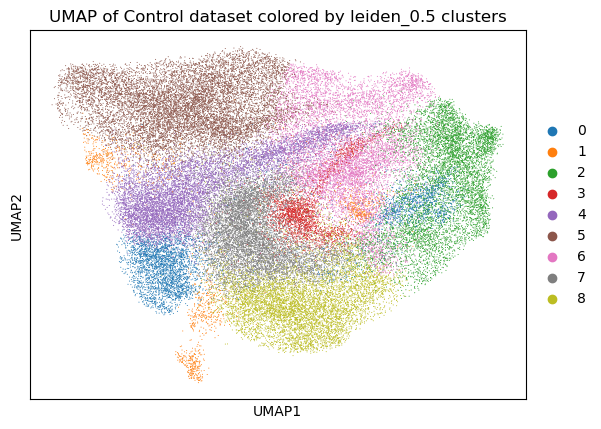

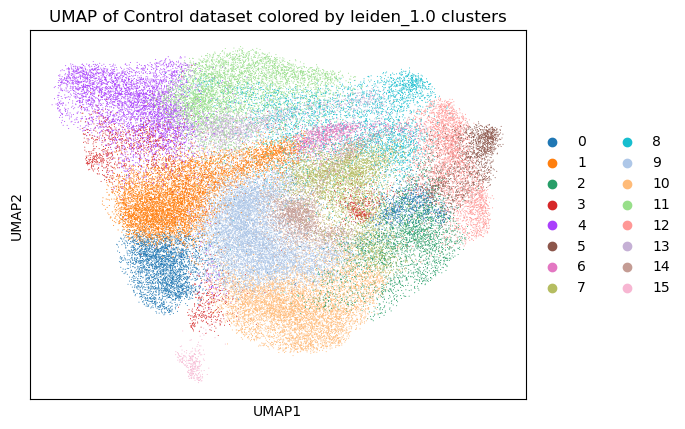

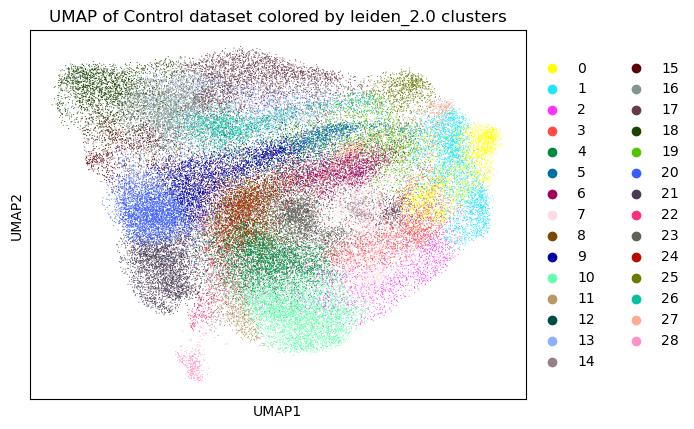

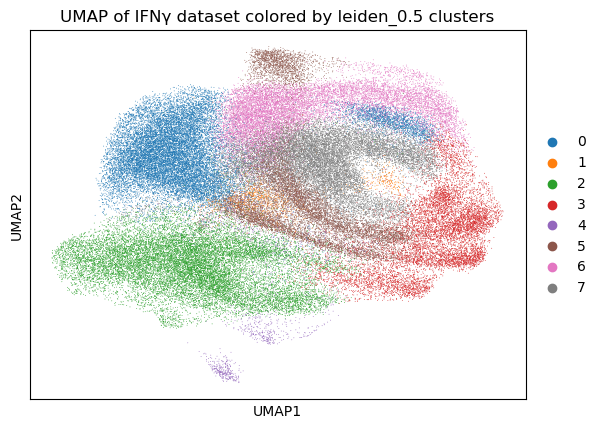

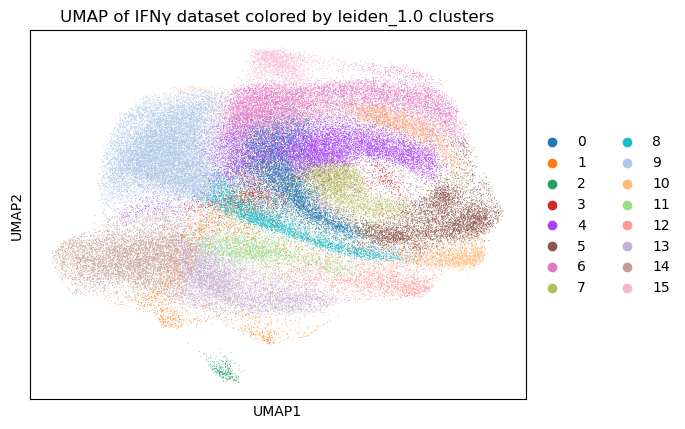

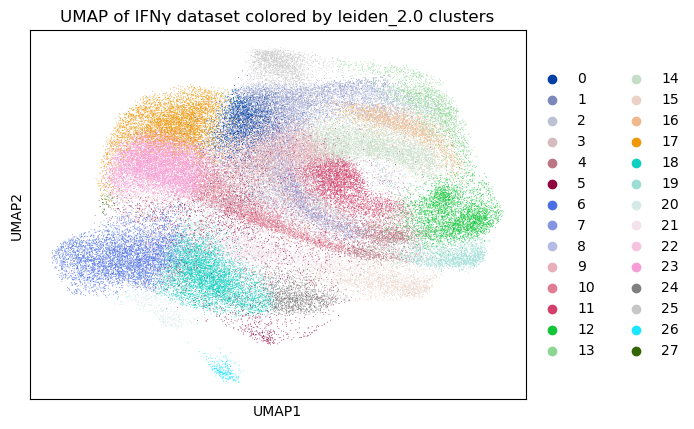

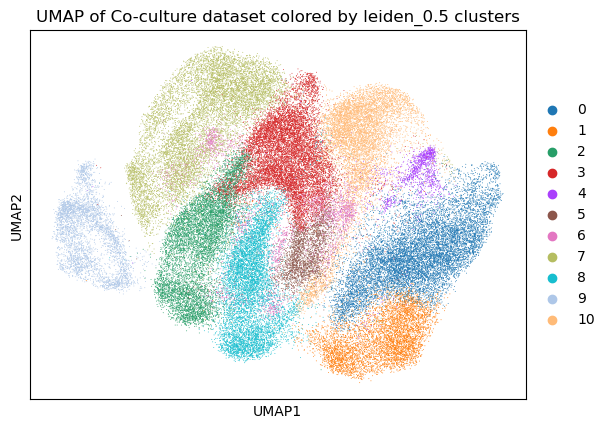

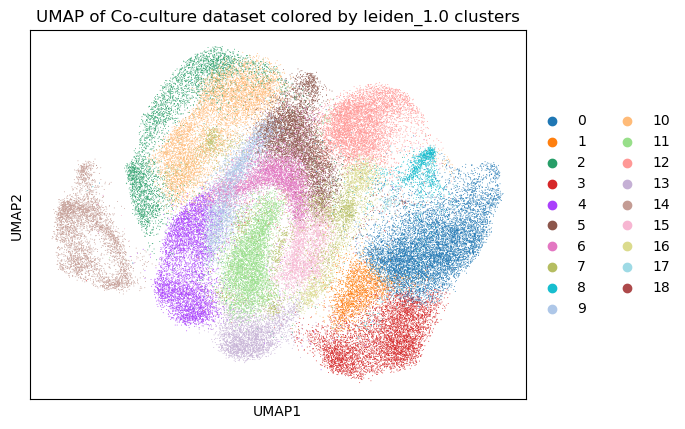

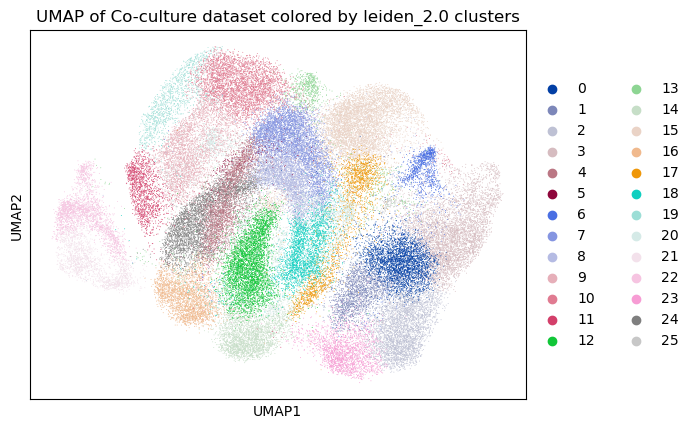

In [23]:
# plot the umaps again and color by leiden clusters for each split dataset and resolution
for key in rna_filtered_split.keys():
    for res in [0.5, 1.0, 2.0]:
        sc.pl.umap(rna_filtered_split[key], color = f"leiden_{res}", title = f"UMAP of {key} dataset colored by leiden_{res} clusters")

In [47]:
# identify which genetic perturbations associate with each leiden cluster 
import pandas as pd

# for each perturbation_2 choose Leiden 1.0 clusters and compute a crosstab of the leiden clusters and perturbation labels, normalized by the number of cells in each leiden cluster
crosstabs = {}
for key in rna_filtered_split.keys():
    leiden_res = rna_filtered_split[key].obs["leiden_1.0"]
    perturbation = rna_filtered_split[key].obs["perturbation"]
    crosstabs[key] = pd.crosstab(leiden_res, perturbation, normalize="columns")

In [ ]:
# compute pairwise correlation between perturbation proportions in each leiden cluster for each condition and then perform hierarchical clustering
correlations = {}
for key in crosstabs.keys():
    correlations[key] = crosstabs[key].corr()

/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/ubuntu/miniconda3/envs/denbi/lib/python3.13/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastclus

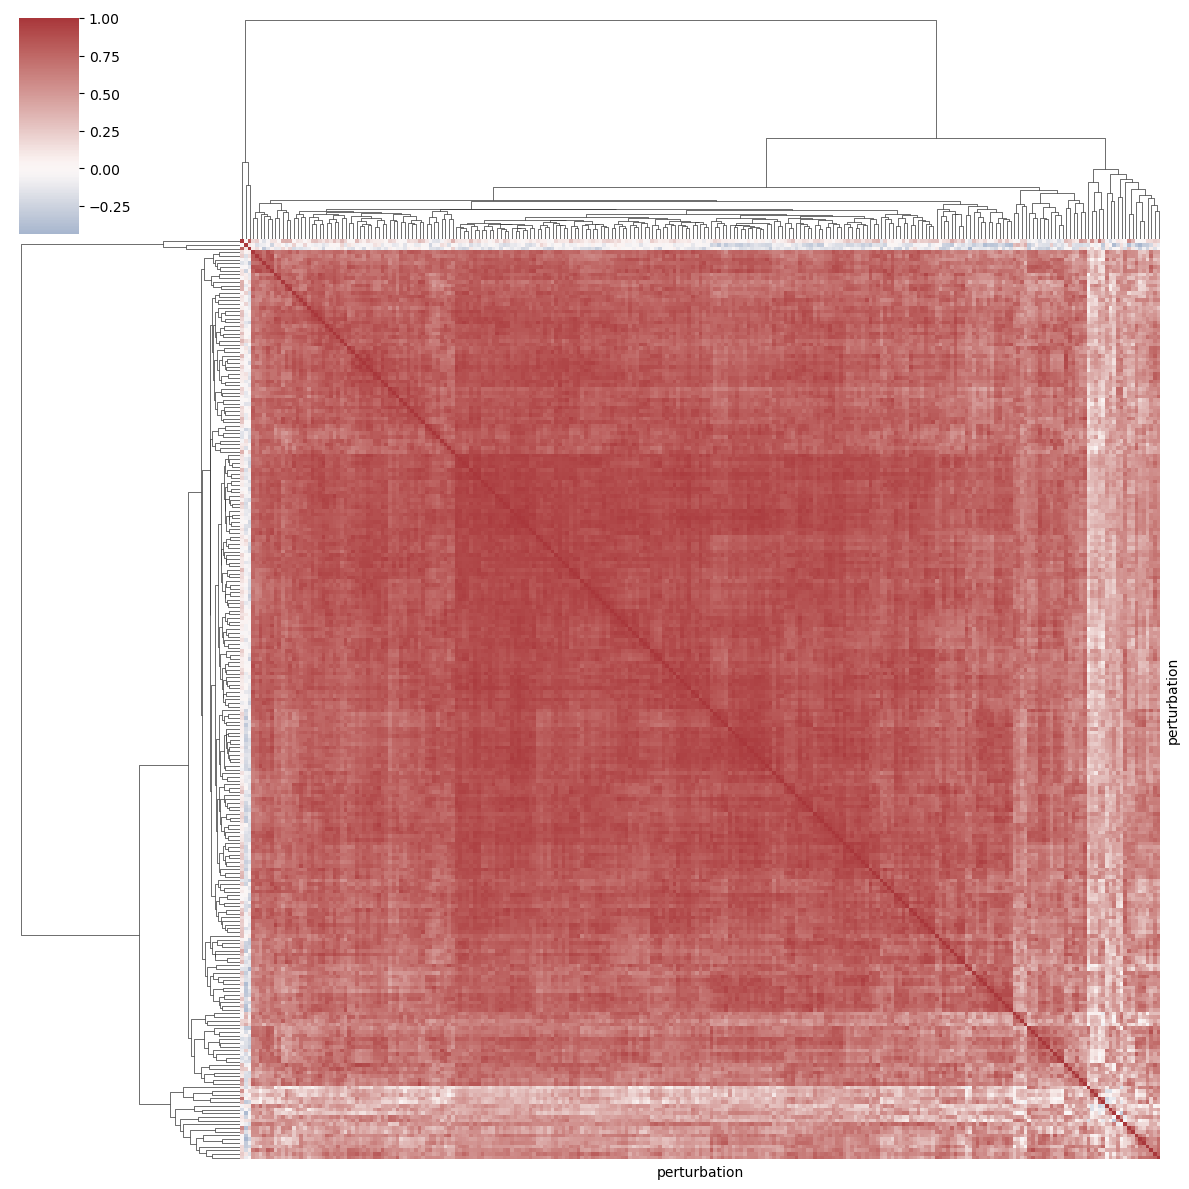

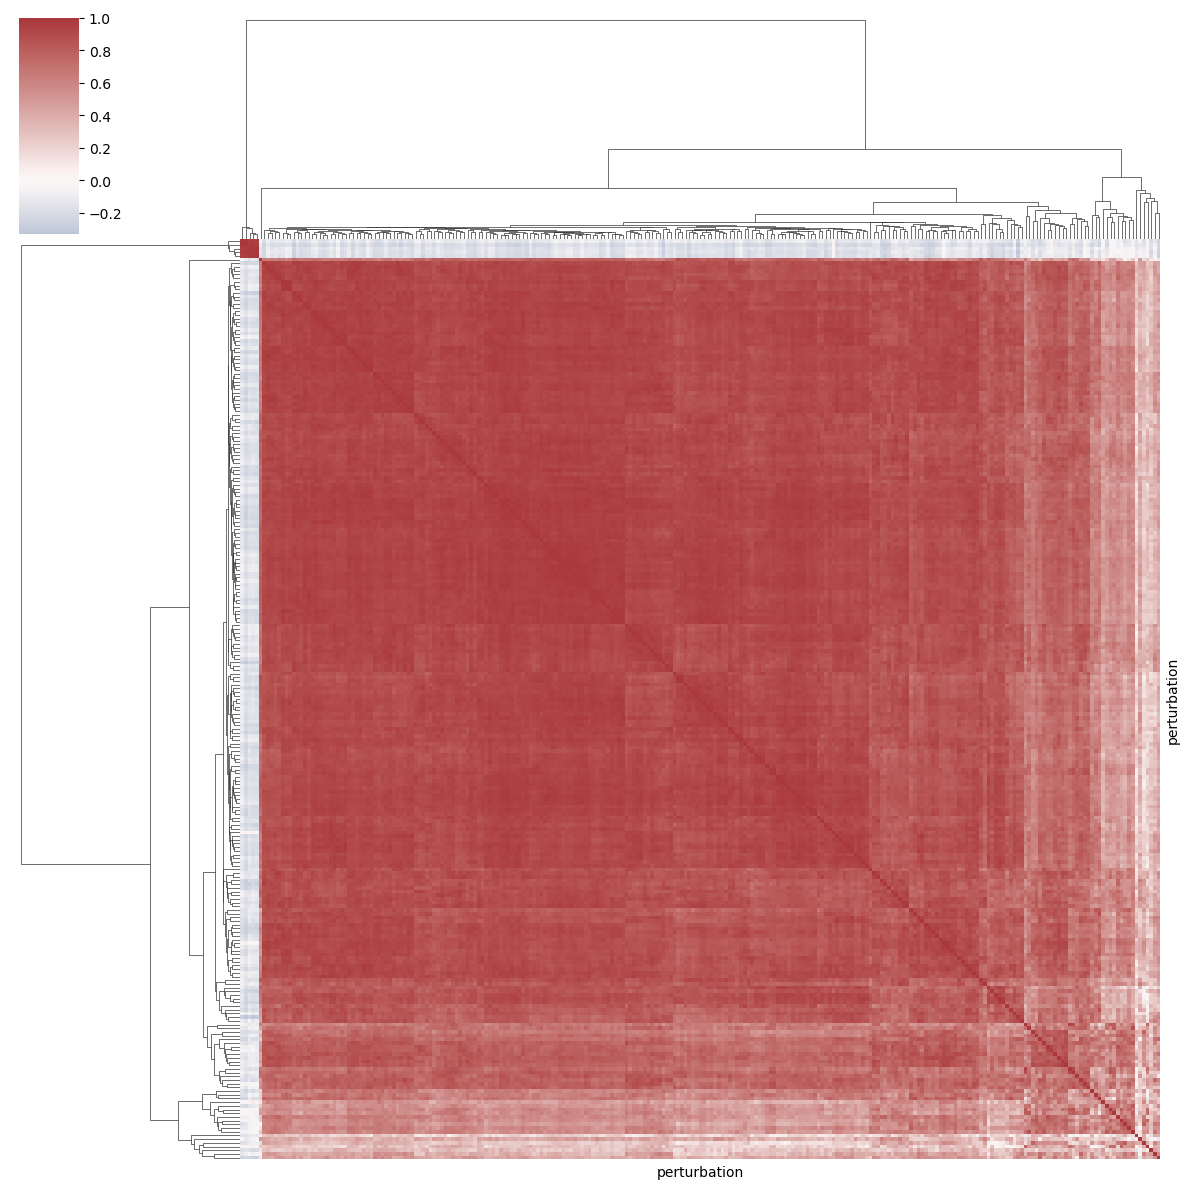

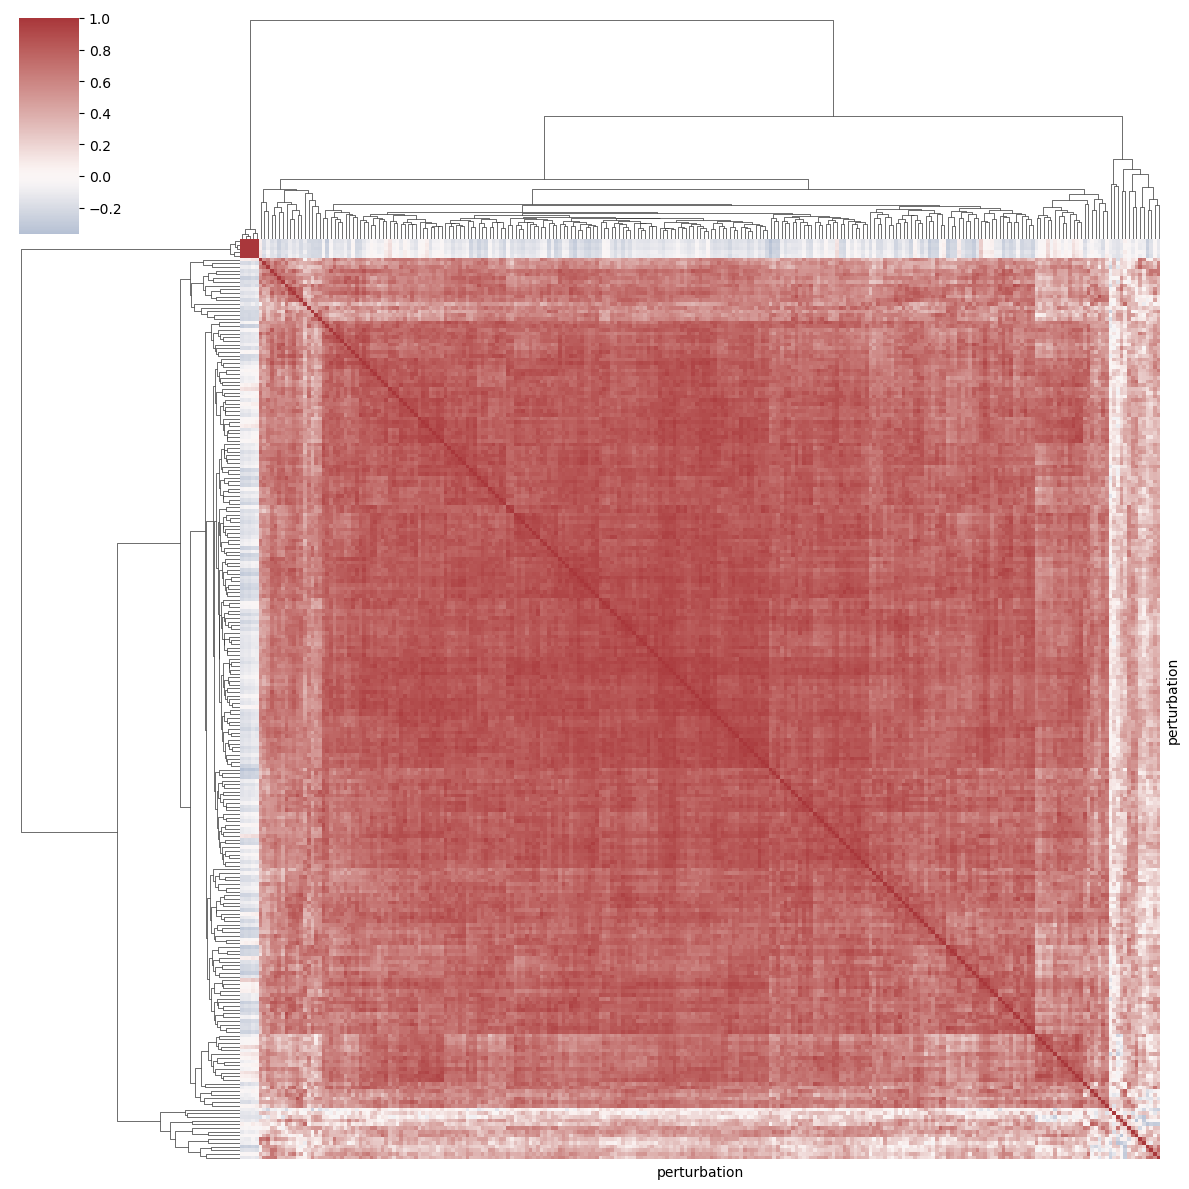

In [53]:
import seaborn as sns

for key in correlations.keys():
    sns.clustermap(
        correlations[key],
        cmap="vlag", center=0,
        figsize=(12, 12),
        xticklabels=False, yticklabels=False,
    )
